In [2]:
import pandas as pd
import numpy as np
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
import pickle




[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Saroon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Saroon\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Saroon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Saroon\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
clinic =pd.read_csv('clinical_trials_raw_patient2trial_conditions.csv') 
clinic.head(2)

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614


In [4]:
clinic.shape

(60337, 16)

In [5]:
clinic.columns.tolist()

['source_condition_query',
 'nct_id',
 'title',
 'official_title',
 'brief_summary',
 'conditions',
 'interventions',
 'overall_status',
 'study_type',
 'phase',
 'sex',
 'minimum_age',
 'maximum_age',
 'healthy_volunteers',
 'eligibility_criteria',
 'clinicaltrials_url']

In [6]:
clinic.isnull().sum()

source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64

In [7]:

print("Unique Disease Categories:")
print(clinic['source_condition_query'].unique())

print("\nTotal number of categories:", 
      clinic['source_condition_query'].nunique())

Unique Disease Categories:
<ArrowStringArray>
[                        'breast cancer',
                              'covid-19',
 'chronic obstructive pulmonary disease',
                  'rheumatoid arthritis',
                       'type 2 diabetes',
                              'glaucoma',
                               'anxiety',
                    'sickle cell anemia']
Length: 8, dtype: str

Total number of categories: 8


In [8]:
# How many trials does each disease have?
print("Trials per Disease Category:")
print("=" * 45)
print(clinic['source_condition_query'].value_counts())

Trials per Disease Category:
source_condition_query
breast cancer                            16301
type 2 diabetes                          11467
covid-19                                 10153
anxiety                                   9286
chronic obstructive pulmonary disease     6181
rheumatoid arthritis                      3637
glaucoma                                  2173
sickle cell anemia                        1139
Name: count, dtype: int64


In [9]:
clinic.isnull().sum()

source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64

In [10]:
# Drop columns we don't need right now
# =====================================

columns_to_drop = [
    'nct_id',           # Just an ID number
    'title',            # We have brief_summary
    'official_title',   # 786 missing, not needed
    'conditions',       # Not needed
    'interventions',    # 6061 missing, not needed
    'phase'             # 37001 missing, not needed
]

clinic = clinic.drop(columns=columns_to_drop)

print("Columns dropped successfully!")
print("\nRemaining columns:")
print(clinic.columns.tolist())
print("\nNew shape:", clinic.shape)

Columns dropped successfully!

Remaining columns:
['source_condition_query', 'brief_summary', 'overall_status', 'study_type', 'sex', 'minimum_age', 'maximum_age', 'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url']

New shape: (60337, 10)


In [11]:
clinic.isnull().sum()

source_condition_query        0
brief_summary                 0
overall_status                0
study_type                    0
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64

In [12]:
import re

def clean_age(age_value):
    
    # If missing return None
    if pd.isna(age_value):
        return None
    
    age_str = str(age_value)
    
    # Extract number only
    number = re.search(r'\d+', age_str)
    
    if number:
        num = float(number.group())
        
        if 'Month' in age_str:
            return round(num / 12, 1)
        elif 'Day' in age_str:
            return round(num / 365, 1)
        else:
            return num
    
    return None

# Step 1: Clean both columns
clinic['min_age'] = clinic['minimum_age'].apply(clean_age)
clinic['max_age'] = clinic['maximum_age'].apply(clean_age)

# Step 2: Fill min_age NaN with MEAN
min_age_mean = clinic['min_age'].mean()
clinic['min_age'] = clinic['min_age'].fillna(round(min_age_mean, 1))

# Step 3: Fill max_age NaN with 999
clinic['max_age'] = clinic['max_age'].fillna(999)

# Step 4: Drop original messy columns
clinic = clinic.drop(columns=['minimum_age', 'maximum_age'])

print("✅ Age columns cleaned and filled!")
print(f"\nmin_age  → NaN filled with MEAN : {round(min_age_mean, 1)}")
print(f"max_age  → NaN filled with      : 999")
print("\nSample values:")
print("=" * 40)
print(clinic[['min_age', 'max_age']].head(10))
print("\nMissing values remaining:")
print("min_age NaN:", clinic['min_age'].isnull().sum())
print("max_age NaN:", clinic['max_age'].isnull().sum())

✅ Age columns cleaned and filled!

min_age  → NaN filled with MEAN : 21.0
max_age  → NaN filled with      : 999

Sample values:
   min_age  max_age
0     20.0     65.0
1     18.0    999.0
2     44.0     49.0
3     18.0     85.0
4     18.0    999.0
5     21.0    999.0
6     18.0    999.0
7     50.0     69.0
8     18.0     75.0
9     21.0    999.0

Missing values remaining:
min_age NaN: 0
max_age NaN: 0


In [13]:
clinic.isnull().sum()

source_condition_query       0
brief_summary                0
overall_status               0
study_type                   0
sex                         33
healthy_volunteers        1480
eligibility_criteria        11
clinicaltrials_url           0
min_age                      0
max_age                      0
dtype: int64

In [14]:
clinic['sex'] = clinic['sex'].fillna('Both')
clinic['sex'].isnull().sum()

np.int64(0)

In [15]:
columns_to_drop1 = [
    'healthy_volunteers', 
    'eligibility_criteria',
]

clinic = clinic.drop(columns=columns_to_drop1)
clinic.isnull().sum()

source_condition_query    0
brief_summary             0
overall_status            0
study_type                0
sex                       0
clinicaltrials_url        0
min_age                   0
max_age                   0
dtype: int64

In [16]:
columns_to_drop2 = [
    'clinicaltrials_url',
]

clinic = clinic.drop(columns=columns_to_drop2)
clinic.isnull().sum()

source_condition_query    0
brief_summary             0
overall_status            0
study_type                0
sex                       0
min_age                   0
max_age                   0
dtype: int64

In [17]:
# Rename columns to simpler names
clinic = clinic.rename(columns={
    'source_condition_query' : 'disease_category',
    'brief_summary'          : 'text'
})

print("✅ Columns renamed!")
print(clinic.columns.tolist())

# Save clean dataset
clinic.to_csv('clinical_trials_clean.csv', index=False)
print("\n✅ Clean file saved!")
print("Final Shape:", clinic.shape)
clinic.head(2)

✅ Columns renamed!
['disease_category', 'text', 'overall_status', 'study_type', 'sex', 'min_age', 'max_age']

✅ Clean file saved!
Final Shape: (60337, 7)


,disease_category,text,overall_status,study_type,sex,min_age,max_age
0,breast cancer,Breast cancer patients often have perioperativ...,UNKNOWN,INTERVENTIONAL,FEMALE,20.0,65.0
1,breast cancer,Many breast cancer patients experience psychol...,COMPLETED,OBSERVATIONAL,ALL,18.0,999.0


In [18]:
# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

# Get English stop words list
stop_words = set(stopwords.words('english'))

print("✅ NLP libraries ready!")
print(f"\nTotal stop words: {len(stop_words)}")
print("\nSample stop words:")
print(list(stop_words)[:10])

✅ NLP libraries ready!

Total stop words: 198

Sample stop words:
["wouldn't", 'of', "shouldn't", 'i', 'before', 'wouldn', 'below', 'be', 'hasn', 'were']


 ## Cleans one piece of text through 5 steps:
    1. Lowercase
    2. Remove numbers
    3. Remove punctuation
    4. Remove stop words
    5. Lemmatize

In [19]:
def clean_text(text):
    """
    Cleans one piece of text through 5 steps:
    1. Lowercase
    2. Remove numbers
    3. Remove punctuation
    4. Remove stop words
    5. Lemmatize
    """
    
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Step 3: Remove punctuation and special chars
    text = re.sub(r'[^\w\s]', '', text)
    
    # Step 4: Split into words (tokenize)
    words = text.split()
    
    # Step 5: Remove stop words + Lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    # Join words back into sentence
    return ' '.join(words)

print("✅ clean_text function ready!")

# Test it on one example
sample = "Breast cancer patients often have Perioperative PAIN!! (2023) and anxiety."
print("\nBefore:", sample)
print("After :", clean_text(sample))

✅ clean_text function ready!

Before: Breast cancer patients often have Perioperative PAIN!! (2023) and anxiety.
After : breast cancer patient often perioperative pain anxiety


## Cleaning entier  data set 

In [20]:
# Apply cleaning to all 60,337 rows
# This may take 1-2 minutes!

print("Cleaning text... please wait...")
print("=" * 40)

clinic['clean_text'] = clinic['text'].apply(clean_text)

print("✅ Text cleaning complete!")
print("\nBefore vs After comparison:")
print("=" * 40)
print("\nBEFORE:", clinic['text'].iloc[0][:100])
print("\nAFTER :", clinic['clean_text'].iloc[0][:100])

Cleaning text... please wait...
✅ Text cleaning complete!

Before vs After comparison:

BEFORE: Breast cancer patients often have perioperative emotional disorders such as anxiety and depression, 

AFTER : breast cancer patient often perioperative emotional disorder anxiety depression lead poor quality re


In [21]:
# Check our cleaned text column
print("Sample cleaned texts:")
print("=" * 40)

for i in range(3):
    print(f"\nRow {i} Disease: {clinic['disease_category'].iloc[i]}")
    print(f"BEFORE: {clinic['text'].iloc[i][:80]}...")
    print(f"AFTER : {clinic['clean_text'].iloc[i][:80]}...")
    print("-" * 40)

Sample cleaned texts:

Row 0 Disease: breast cancer
BEFORE: Breast cancer patients often have perioperative emotional disorders such as anxi...
AFTER : breast cancer patient often perioperative emotional disorder anxiety depression ...
----------------------------------------

Row 1 Disease: breast cancer
BEFORE: Many breast cancer patients experience psychological distress during their cance...
AFTER : many breast cancer patient experience psychological distress cancer care journey...
----------------------------------------

Row 2 Disease: breast cancer
BEFORE: Based on an American study by Scherer et al., it is hypothesized that some women...
AFTER : based american study scherer et al hypothesized woman make irrational choice reg...
----------------------------------------


In [22]:
# Quick check
print('often' in stop_words)

False


In [23]:
# Let's see what NLTK's stop words actually contain
print(sorted(stop_words))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [24]:
from collections import Counter

# Combine all cleaned text into one giant list of words
all_words = ' '.join(clinic['clean_text']).split()

# Count word frequency
word_freq = Counter(all_words)

# Show top 30 most common words
print("Top 30 Most Common Words in Cleaned Text:")
print("=" * 50)
for word, count in word_freq.most_common(30):
    print(f"{word:20s} → {count}")

Top 30 Most Common Words in Cleaned Text:
study                → 77875
patient              → 72456
treatment            → 33326
cancer               → 29998
breast               → 26027
group                → 20722
disease              → 20107
effect               → 19592
covid                → 18074
participant          → 18005
clinical             → 17791
intervention         → 17013
therapy              → 16513
trial                → 16024
diabetes             → 15759
anxiety              → 15592
evaluate             → 15346
aim                  → 14834
health               → 13814
type                 → 13770
care                 → 13675
safety               → 13306
week                 → 12892
control              → 12369
may                  → 12317
cell                 → 11829
purpose              → 11648
efficacy             → 11508
blood                → 11483
randomized           → 11252


In [25]:
# Save the dataset with clean_text column included
clinic.to_csv('clinical_trials_clean.csv', index=False)

print("✅ Saved with clean_text column!")
print("Shape:", clinic.shape)
print("\nColumns:", clinic.columns.tolist())

✅ Saved with clean_text column!
Shape: (60337, 8)

Columns: ['disease_category', 'text', 'overall_status', 'study_type', 'sex', 'min_age', 'max_age', 'clean_text']


 TF-IDF ? or eda 

In [26]:
clinic.isnull().sum()

disease_category    0
text                0
overall_status      0
study_type          0
sex                 0
min_age             0
max_age             0
clean_text          0
dtype: int64

## EDA

In [27]:
#Set a nice style for our charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Visualization libraries ready!")

✅ Visualization libraries ready!


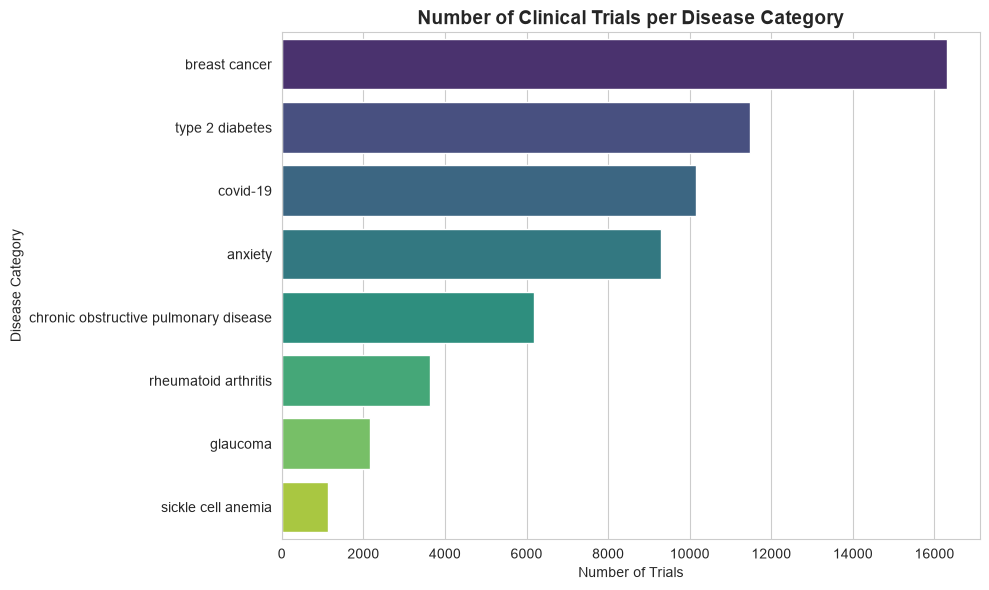

Disease Distribution:
disease_category
breast cancer                            16301
type 2 diabetes                          11467
covid-19                                 10153
anxiety                                   9286
chronic obstructive pulmonary disease     6181
rheumatoid arthritis                      3637
glaucoma                                  2173
sickle cell anemia                        1139
Name: count, dtype: int64


In [28]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Count trials per disease
disease_counts = clinic['disease_category'].value_counts()

# Create bar chart - FIXED VERSION
plt.figure(figsize=(10, 6))
sns.barplot(x=disease_counts.values, 
            y=disease_counts.index,
            hue=disease_counts.index,
            palette='viridis',
            legend=False)

plt.title('Number of Clinical Trials per Disease Category', 
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Trials')
plt.ylabel('Disease Category')
plt.tight_layout()
plt.show()

print("Disease Distribution:")
print(disease_counts)

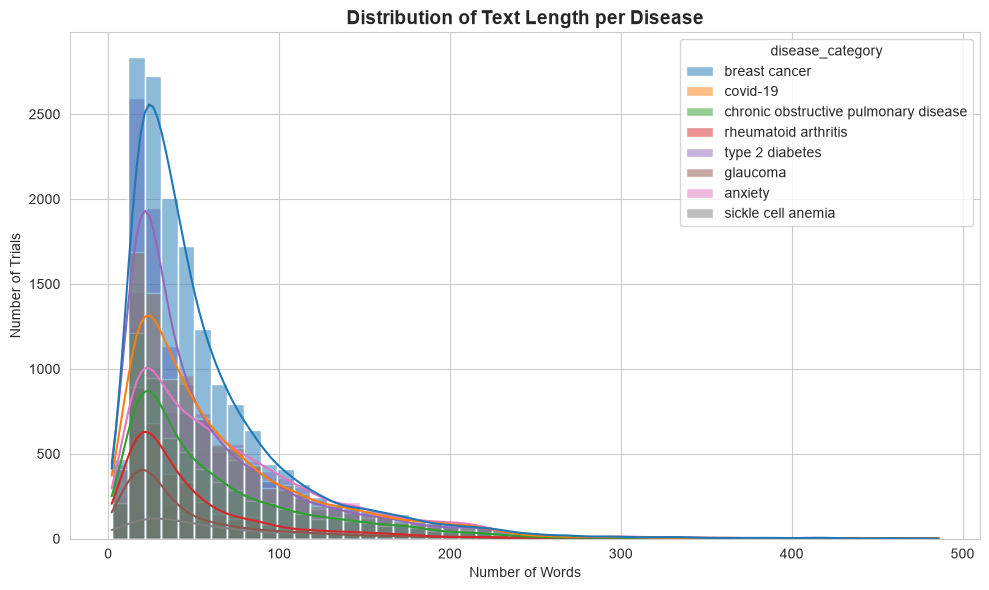

Average word count per disease:
disease_category
anxiety                                  73.8
sickle cell anemia                       72.3
covid-19                                 66.4
chronic obstructive pulmonary disease    63.3
breast cancer                            58.4
type 2 diabetes                          58.2
rheumatoid arthritis                     50.7
glaucoma                                 46.9
Name: word_count, dtype: float64


In [29]:
# Chart 2: Text Length Distribution
# ====================================

# Calculate word count for each text
clinic['word_count'] = clinic['clean_text'].apply(
                        lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=clinic, 
             x='word_count',
             hue='disease_category',
             bins=50,
             kde=True)

plt.title('Distribution of Text Length per Disease',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Number of Trials')
plt.tight_layout()
plt.show()

print("Average word count per disease:")
print("=" * 45)
print(clinic.groupby('disease_category')['word_count']
      .mean().round(1).sort_values(ascending=False))

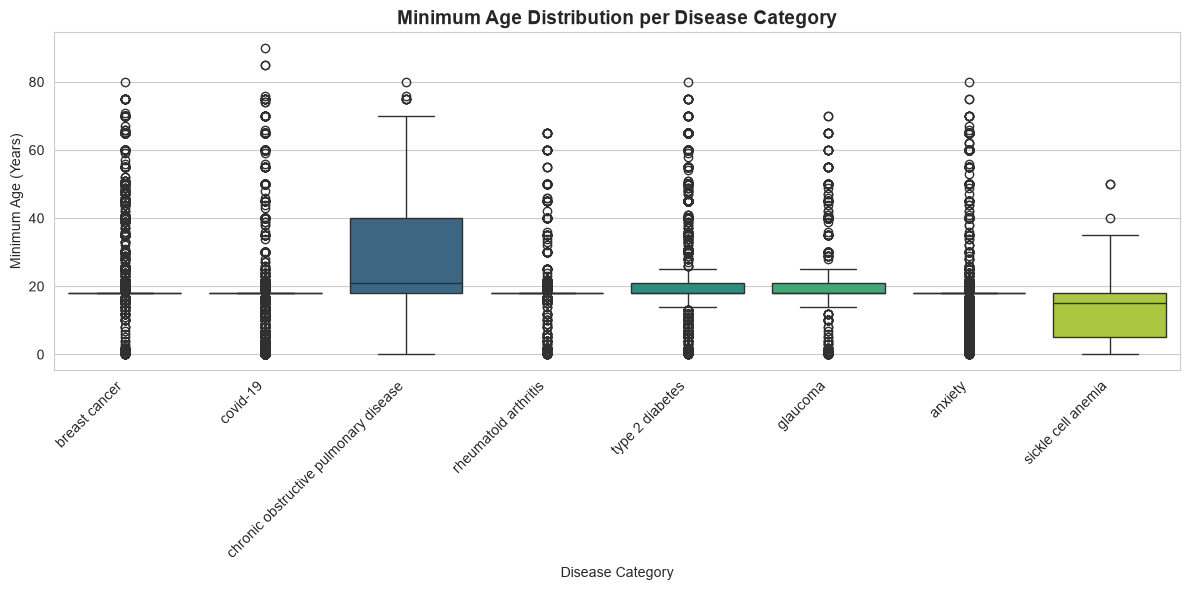

Average Minimum Age per Disease:
disease_category
chronic obstructive pulmonary disease    29.2
type 2 diabetes                          22.8
glaucoma                                 22.0
breast cancer                            20.7
rheumatoid arthritis                     19.0
covid-19                                 18.9
anxiety                                  18.0
sickle cell anemia                       12.2
Name: min_age, dtype: float64


In [30]:
# Chart 3: Age vs Disease (Box Plot)
# =====================================

plt.figure(figsize=(12, 6))
sns.boxplot(data=clinic,
            x='disease_category',
            y='min_age',
            hue='disease_category',
            palette='viridis',
            legend=False)

plt.title('Minimum Age Distribution per Disease Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Disease Category')
plt.ylabel('Minimum Age (Years)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print average ages per disease
print("Average Minimum Age per Disease:")
print("=" * 45)
print(clinic.groupby('disease_category')['min_age']
      .mean().round(1).sort_values(ascending=False))


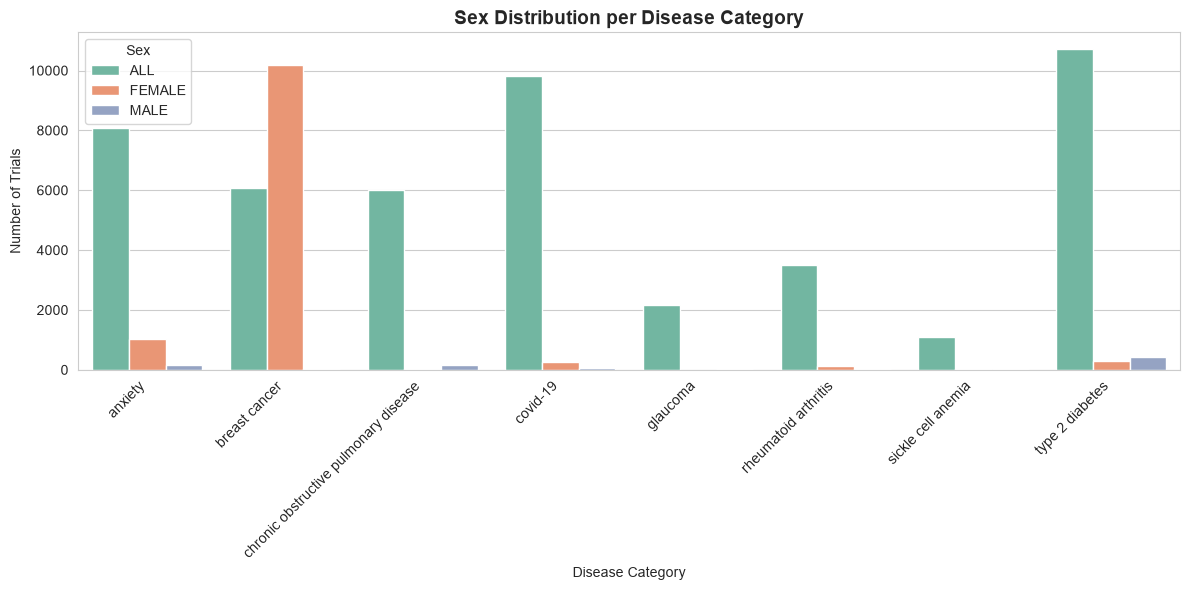

Sex distribution per disease:
sex                                      ALL  FEMALE  MALE
disease_category                                          
anxiety                                 8085    1027   174
breast cancer                           6073   10185    43
chronic obstructive pulmonary disease   5999      29   153
covid-19                                9833     244    76
glaucoma                                2157       1    15
rheumatoid arthritis                    3488     114    35
sickle cell anemia                      1100      22    17
type 2 diabetes                        10734     303   430


In [31]:
# Merge ALL and Both into one category
clinic['sex'] = clinic['sex'].replace('Both', 'ALL')

# Now recreate the chart
plt.figure(figsize=(12, 6))

sex_data = clinic.groupby(
    ['disease_category', 'sex']).size().reset_index(name='count')

sns.barplot(data=sex_data,
            x='disease_category',
            y='count',
            hue='sex',
            palette='Set2')

plt.title('Sex Distribution per Disease Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Disease Category')
plt.ylabel('Number of Trials')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

# Print counts
print("Sex distribution per disease:")
print("=" * 45)
print(clinic.groupby(['disease_category','sex'])
      .size().unstack(fill_value=0))

In [32]:
clinic.isnull().sum()

disease_category    0
text                0
overall_status      0
study_type          0
sex                 0
min_age             0
max_age             0
clean_text          0
word_count          0
dtype: int64

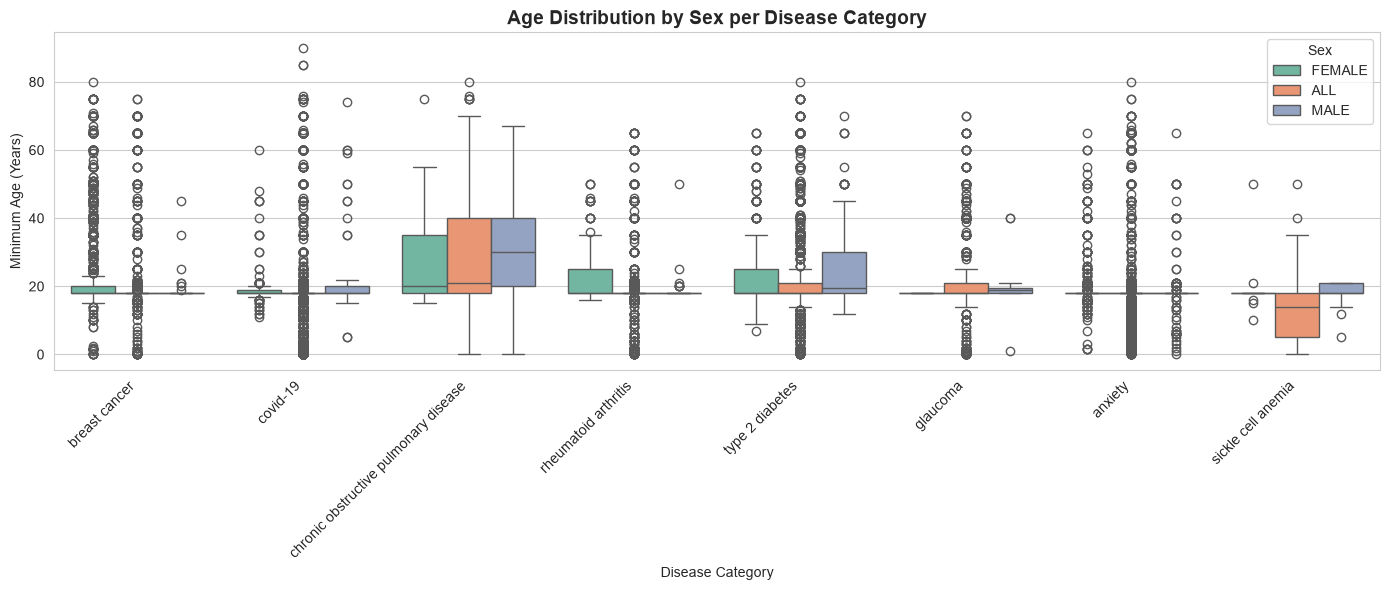

In [33]:
# EDA: Age vs Sex per Disease
# ==============================

plt.figure(figsize=(14, 6))
sns.boxplot(data=clinic,
            x='disease_category',
            y='min_age',
            hue='sex',
            palette='Set2')

plt.title('Age Distribution by Sex per Disease Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Disease Category')
plt.ylabel('Minimum Age (Years)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

In [34]:
# Average min age grouped by disease AND sex
print("Average Minimum Age by Sex per Disease:")
print("=" * 50)
print(clinic.groupby(['disease_category', 'sex'])['min_age']
      .mean().round(1).unstack())

Average Minimum Age by Sex per Disease:
sex                                     ALL  FEMALE  MALE
disease_category                                         
anxiety                                17.7    19.5  19.1
breast cancer                          19.2    21.6  19.4
chronic obstructive pulmonary disease  29.1    28.3  32.6
covid-19                               18.9    19.4  22.7
glaucoma                               22.0    18.0  20.5
rheumatoid arthritis                   18.8    23.5  19.5
sickle cell anemia                     12.0    19.0  17.7
type 2 diabetes                        22.7    24.3  24.5


## Build TF-IDF

In [35]:
# Step 1: Define our INPUT and OUTPUT
X = clinic['clean_text']        # Input  → text
y = clinic['disease_category']  # Output → disease label

print("Input shape :", X.shape)
print("Output shape:", y.shape)
print("\nSample Input:")
print(X.iloc[0][:100])
print("\nSample Output:")
print(y.iloc[0])

Input shape : (60337,)
Output shape: (60337,)

Sample Input:
breast cancer patient often perioperative emotional disorder anxiety depression lead poor quality re

Sample Output:
breast cancer


## CELL 2 — Split Data into Train and Test


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,              # our text input
    y,              # our disease labels
    test_size=0.2,  # 20% for testing
    random_state=42 # ensures same split every time
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("\nSplit breakdown:")
print(f"Train: {len(X_train)/len(X)*100:.0f}% of data")
print(f"Test : {len(X_test)/len(X)*100:.0f}% of data")

Training samples: 48269
Testing samples : 12068

Split breakdown:
Train: 80% of data
Test : 20% of data


## apply  TF-IDF


In [37]:
# Step 3: Convert text to numbers using TF-IDF
# ==============================================

tfidf = TfidfVectorizer(
    max_features=5000,  # use top 5000 words only
    ngram_range=(1,2),  # use single words AND pairs
    min_df=2            # ignore very rare words
)

# LEARN vocabulary from training data
# CONVERT training text to numbers
X_train_tfidf = tfidf.fit_transform(X_train)

# CONVERT test text to numbers
# (using same vocabulary!)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF complete!")
print("\nTraining matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape :", X_test_tfidf.shape)
print("\nThis means:")
print(f"{X_train_tfidf.shape[0]} documents")
print(f"{X_train_tfidf.shape[1]} unique words (features)")

✅ TF-IDF complete!

Training matrix shape: (48269, 5000)
Testing matrix shape : (12068, 5000)

This means:
48269 documents
5000 unique words (features)


In [38]:
print("Training Logistic Regression...")
print("=" * 40)
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)
lr_predictions = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"✅ Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

Training Logistic Regression...
✅ Logistic Regression Accuracy: 94.06%


In [39]:
print("Training Naive Bayes...")
print("=" * 40)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_predictions)

print(f"✅ Naive Bayes Accuracy: {nb_accuracy*100:.2f}%")

Training Naive Bayes...
✅ Naive Bayes Accuracy: 89.85%


In [40]:
print("MODEL COMPARISON:")
print("=" * 45)
print(f"Logistic Regression : {lr_accuracy*100:.2f}%")
print(f"Naive Bayes         : {nb_accuracy*100:.2f}%")
print("\nBest Model:",
      "Logistic Regression" if lr_accuracy > nb_accuracy
      else "Naive Bayes")

# Detailed report of best model
print("\nDetailed Report - Logistic Regression:")
print("=" * 45)
print(classification_report(y_test, lr_predictions))

MODEL COMPARISON:
Logistic Regression : 94.06%
Naive Bayes         : 89.85%

Best Model: Logistic Regression

Detailed Report - Logistic Regression:
                                       precision    recall  f1-score   support

                              anxiety       0.89      0.94      0.92      1921
                        breast cancer       0.96      0.97      0.96      3259
chronic obstructive pulmonary disease       0.94      0.89      0.91      1251
                             covid-19       0.95      0.93      0.94      1925
                             glaucoma       0.97      0.93      0.95       456
                 rheumatoid arthritis       0.97      0.88      0.92       738
                   sickle cell anemia       0.97      0.84      0.90       227
                      type 2 diabetes       0.94      0.97      0.96      2291

                             accuracy                           0.94     12068
                            macro avg       0.95      0.92 

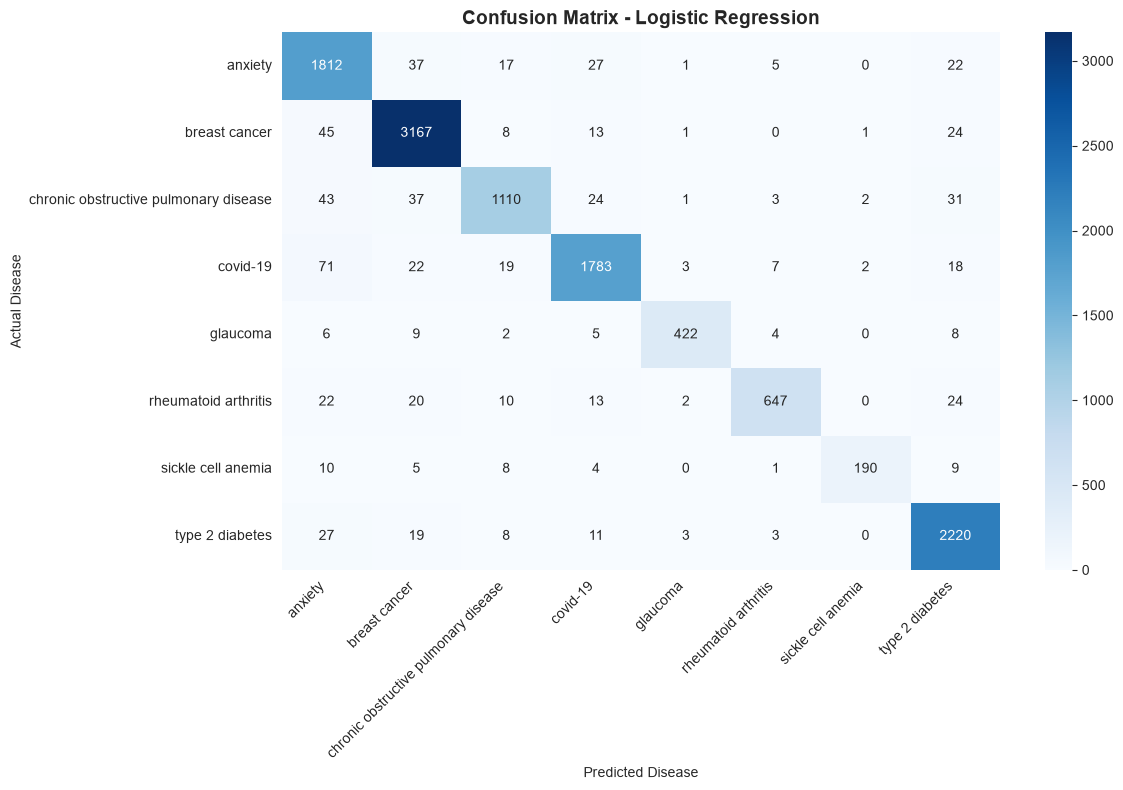

In [41]:
# Confusion Matrix - Visual representation
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_predictions)
labels = sorted(y_test.unique())

plt.figure(figsize=(12, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - Logistic Regression',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Disease')
plt.xlabel('Predicted Disease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Random Forest

In [42]:


print("Training Random Forest...")
print("=" * 40)

rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)
rf_predictions = rf_model.predict(X_test_tfidf)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"✅ Random Forest Accuracy: {rf_accuracy*100:.2f}%")

Training Random Forest...
✅ Random Forest Accuracy: 93.48%


## SVM 

In [43]:

print("Training SVM...")
print("=" * 40)

svm_model = LinearSVC(
    random_state=42,
    max_iter=1000
)

svm_model.fit(X_train_tfidf, y_train)
svm_predictions = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"✅ SVM Accuracy: {svm_accuracy*100:.2f}%")

Training SVM...
✅ SVM Accuracy: 94.13%


## Decision Tree...

In [44]:
print("Training Decision Tree...")
print("=" * 40)

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_tfidf, y_train)
dt_predictions = dt_model.predict(X_test_tfidf)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print(f"✅ Decision Tree Accuracy: {dt_accuracy*100:.2f}%")

Training Decision Tree...
✅ Decision Tree Accuracy: 90.26%


In [45]:
# Final comparison of ALL models
print("FINAL MODEL COMPARISON:")
print("=" * 45)

results = {
    'Logistic Regression' : lr_accuracy * 100,
    'Naive Bayes'         : nb_accuracy * 100,
    'Random Forest'       : rf_accuracy * 100,
    'SVM'                 : svm_accuracy * 100,
    'Decision Tree'       : dt_accuracy * 100
}

# Sort by accuracy
results = dict(sorted(results.items(), 
               key=lambda x: x[1], 
               reverse=True))

for model, acc in results.items():
    bar = '█' * int(acc // 5)
    print(f"{model:25s} → {acc:.2f}% {bar}")

best_model = max(results, key=results.get)
print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   Accuracy  : {results[best_model]:.2f}%")

FINAL MODEL COMPARISON:
SVM                       → 94.13% ██████████████████
Logistic Regression       → 94.06% ██████████████████
Random Forest             → 93.48% ██████████████████
Decision Tree             → 90.26% ██████████████████
Naive Bayes               → 89.85% █████████████████

🏆 BEST MODEL: SVM
   Accuracy  : 94.13%


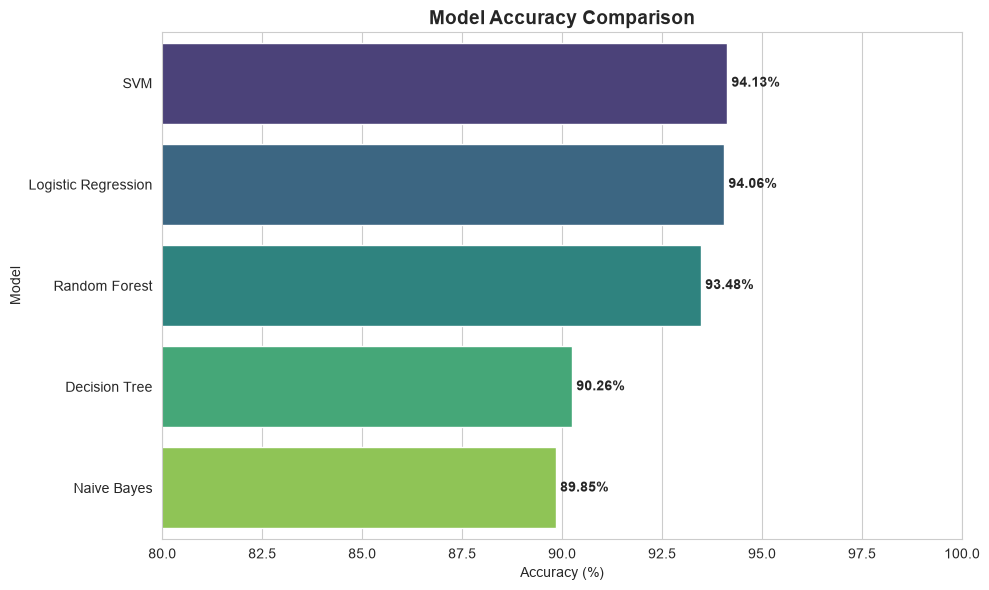

In [46]:
# Bar chart comparing all models
plt.figure(figsize=(10, 6))

models = list(results.keys())
accuracies = list(results.values())

sns.barplot(x=accuracies,
            y=models,
            hue=models,
            palette='viridis',
            legend=False)

plt.title('Model Accuracy Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.xlim(80, 100)

for i, acc in enumerate(accuracies):
    plt.text(acc + 0.1, i, 
             f'{acc:.2f}%', 
             va='center',
             fontweight='bold')

plt.tight_layout()
plt.show()

## saving as pickle file

In [47]:
# Save Logistic Regression model
with open('disease_classifier.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model saved    → disease_classifier.pkl")
print("✅ TF-IDF saved   → tfidf_vectorizer.pkl")
print("\nThese 2 files will be used in Streamlit!")

✅ Model saved    → disease_classifier.pkl
✅ TF-IDF saved   → tfidf_vectorizer.pkl

These 2 files will be used in Streamlit!


## Testing model 

In [48]:
# Test our saved model on new text!
# =====================================

def predict_disease(text):
    # Step 1: Clean the text
    cleaned = clean_text(text)
    
    # Step 2: Convert to TF-IDF numbers
    text_tfidf = tfidf.transform([cleaned])
    
    # Step 3: Predict!
    prediction = lr_model.predict(text_tfidf)
    
    return prediction[0]

# Test with sample texts
test_texts = [
    "Patient shows high blood sugar levels and insulin resistance",
    "Tumor found in breast tissue, chemotherapy recommended",
    "Eye pressure elevated causing optic nerve damage",
    "Severe anxiety and panic attacks affecting daily life",
    "severe chest pain"
]

print("🧪 Testing our model:")
print("=" * 50)
for text in test_texts:
    prediction = predict_disease(text)
    print(f"\nText: {text[:50]}...")
    print(f"Predicted: {prediction} ✅")

🧪 Testing our model:

Text: Patient shows high blood sugar levels and insulin ...
Predicted: type 2 diabetes ✅

Text: Tumor found in breast tissue, chemotherapy recomme...
Predicted: breast cancer ✅

Text: Eye pressure elevated causing optic nerve damage...
Predicted: glaucoma ✅

Text: Severe anxiety and panic attacks affecting daily l...
Predicted: anxiety ✅

Text: severe chest pain...
Predicted: anxiety ✅


In [49]:
# If not run yet — run this now!
def predict_disease_with_confidence(text):
    cleaned = clean_text(text)
    text_tfidf = tfidf.transform([cleaned])
    prediction = lr_model.predict(text_tfidf)[0]
    probabilities = lr_model.predict_proba(text_tfidf)[0]
    confidence = max(probabilities) * 100
    return prediction, confidence

test_texts = [
    "Patient shows high blood sugar and insulin resistance",
    "Tumor found in breast tissue chemotherapy recommended",
    "Eye pressure elevated causing optic nerve damage",
    "Severe anxiety and panic attacks affecting daily life",
    "severe chest pain"
]

print("🧪 Testing with Confidence Scores:")
print("=" * 55)
for text in test_texts:
    pred, conf = predict_disease_with_confidence(text)
    print(f"\nText      : {text[:45]}...")
    print(f"Predicted : {pred}")
    print(f"Confidence: {conf:.1f}%")
    if conf < 50:
        print("⚠️ LOW CONFIDENCE - might be wrong!")

🧪 Testing with Confidence Scores:

Text      : Patient shows high blood sugar and insulin re...
Predicted : type 2 diabetes
Confidence: 97.1%

Text      : Tumor found in breast tissue chemotherapy rec...
Predicted : breast cancer
Confidence: 100.0%

Text      : Eye pressure elevated causing optic nerve dam...
Predicted : glaucoma
Confidence: 93.5%

Text      : Severe anxiety and panic attacks affecting da...
Predicted : anxiety
Confidence: 96.4%

Text      : severe chest pain...
Predicted : anxiety
Confidence: 23.3%
⚠️ LOW CONFIDENCE - might be wrong!
